In [7]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import *
from scipy.stats import rankdata
from utils.mesh_utils import get_square_f
from utils.metrics import SpaceIndexing, error_centroid, error_movers, error_iou, error_ssim
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, tikhonov_solver, get_approximate_W
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

In [2]:
# Function space
n = 64
mesh = UnitSquareMesh(n, n)
V_h = FunctionSpace(mesh, 'CG', 1)

# Matrix-free rSVD
rsvd = MatrixFreeRSVD(V_h)

# Source f and output y
x0, y0, width, height = 0.2, 0.2, 0.15, 0.15
f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
x = f.vector().get_local()
y = rsvd.apply_K(x)

In [18]:
k_list = [5] * 3 + [15] * 3 + [50] * 3
lambda_list = [1e-1, 1e-2, 1e-4] * 3

def compute_all_errors(x, x_hat, f_hat, indexing):
    record = {}
    record['f'] = f_hat.copy()
    record['x'] = x_hat.copy()
    record["euclidean"] = np.linalg.norm(x - x_hat)
    record["centroid"] = error_centroid(x, x_hat)
    record["movers"] = error_movers(x, x_hat)
    record["iou"] = error_iou(x, x_hat, indexing)
    record["ssim"] = error_ssim(x, x_hat, indexing)
    return record


indexing = SpaceIndexing(V_h)
records = []
for k, lambda_ in zip(k_list, lambda_list):    
    # Approximate K and W
    U, S, VT = rsvd.mf_rsvd(k=k)
    w = get_approximate_W(VT.T, rsvd.M_dx)

    # Solve weighted Tikhonov problem
    x_hat = tikhonov_solver(rsvd, w, y, lambda_=lambda_)
    f_hat = Function(V_h)
    f_hat.vector()[:] = x_hat   

    record = compute_all_errors(x, x_hat, f_hat, indexing)
    records.append(record)

exact = ExactForwardOperator(V_h)
K = exact.K
w = exact.get_weights()

for lambda_ in lambda_list[:3]:
    print(lambda_)
    f_hat = solve_explicit(operator=exact, w=w, y=y, lambda_=lambda_)
    x_hat = f_hat.vector().get_local()
    record = compute_all_errors(x, x_hat, f_hat, indexing)
    records.append(record)

Assembling S...
Assembling T...
0.1
0.01
0.0001


In [19]:
metrics = ["euclidean", "centroid", "movers", "iou", "ssim"]
for metric in metrics:
    values = np.array([r[metric] for r in records])

    # For metrics where smaller = better
    if metric not in ["iou", "ssim"]:
        ranks = rankdata(values, method="min")
    else:
        # For metrics where larger = better
        ranks = rankdata(-values, method="min")

    for r, rank in zip(records, ranks):
        r[f"{metric}_rank"] = int(rank)

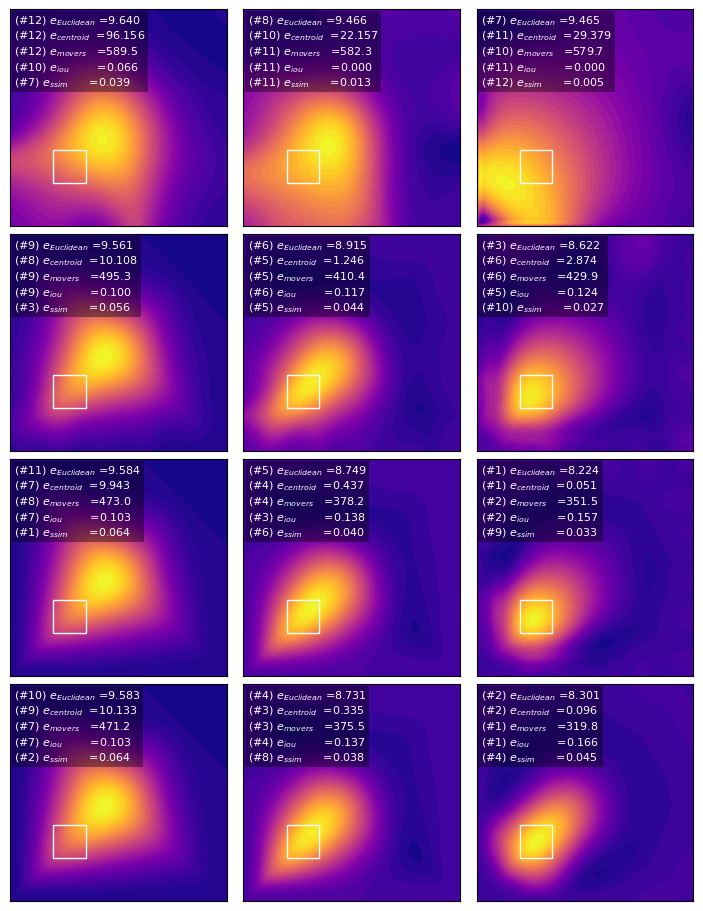

In [22]:
def plot_multiple_f(records, names=None):
    import matplotlib.patches as patches
    fig, axes = plt.subplots(4, 3, figsize=(7, 9), constrained_layout=True)
    axes = axes.flatten()

    if names is None:
        names = ['' for _ in axes]

    for i, (ax, record) in enumerate(zip(axes, records)):
        plt.sca(ax)
        p = plot(record['f'], cmap='plasma')
        #fig.colorbar(p, ax=ax, format="%.2f", shrink=0.9)
        ax.set_xticks([])
        ax.set_yticks([])
        square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
        ax.add_patch(square)

        text = (
            f"(#{record['euclidean_rank']}) $e_{{Euclidean}}$ ={record['euclidean']:.3f}\n"
            f"(#{record['centroid_rank']}) $e_{{centroid}}$  ={record['centroid']:.3f}\n"
            f"(#{record['movers_rank']}) $e_{{movers}}$   ={record['movers']:.1f}\n"
            f"(#{record['iou_rank']}) $e_{{iou}}$        ={record['iou']:.3f}\n"
            f"(#{record['ssim_rank']}) $e_{{ssim}}$      ={record['ssim']:.3f}"
        )
        ax.text(
            0.02, 0.98, text,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=8,
            color="white",
            bbox=dict(facecolor="black", alpha=0.4, pad=2, edgecolor="none")
        )

plot_multiple_f(records)

Basert på dette, så velger jeg å bruke:
 - centroid
 - Movers
 - IoU